# The same tiny network — now in PyTorch

In the first notebook (`simple_training.ipynb`) you wrote **every gradient by hand**:
the forward pass, the loss, the backward pass (chain rule), and the weight update — all
in numpy.

Now we build the **exact same model** with PyTorch and let the framework do the
calculus for you. The whole hand-written backward block collapses into a single line:

```python
loss.backward()
```

And here's the punchline of this notebook: in Section 8 we **prove** that PyTorch's
`autograd` computes the *same gradients* your numpy code did — down to ~1e-6.

Same problem as before: predict whether a student is **admitted** (1) or **not** (0)
from `hours_studied` and `hours_slept`.

Run the cells top to bottom (Shift+Enter). The last sections have **sliders**.

## 1. Setup

Same tools as before, plus **PyTorch** (`torch`). `torch.nn` has ready-made layers;
`torch.optim` has ready-made optimizers.

In [1]:
import csv
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["figure.dpi"] = 100

# same colours as the from-scratch notebook, so the two match visually
CMAP_PTS = ListedColormap(["#e8623c", "#2a9d8f"])   # points
CMAP_BG  = ListedColormap(["#fbe3da", "#d6efeb"])    # decision-boundary fill

print("torch", torch.__version__)

torch 2.12.1


## 2. Load the data (identical to before)

Exactly the same `load_csv` and `normalize` as the first notebook. The only new step:
we wrap the arrays in **tensors** — PyTorch's version of a numpy array that can also
track gradients.

In [2]:
def find_data():
    # Locate data.csv whether we run from the notebook folder or the repo root.
    for p in [Path("data.csv"), Path("simple_training/data.csv")]:
        if p.exists():
            return p
    raise FileNotFoundError("data.csv not found next to the notebook")

def load_csv(path):
    rows = list(csv.DictReader(open(path, newline="")))
    X = np.array([[float(r["hours_studied"]), float(r["hours_slept"])] for r in rows])
    y = np.array([[float(r["admitted"])] for r in rows])
    return X, y

def normalize(X):
    mean, std = X.mean(axis=0), X.std(axis=0)
    return (X - mean) / std, mean, std

X_raw, y = load_csv(find_data())
X, mean, std = normalize(X_raw)

# to tensors (float32 is the PyTorch default)
Xt = torch.tensor(X, dtype=torch.float32)
yt = torch.tensor(y, dtype=torch.float32)

print(f"{X_raw.shape[0]} students, {X_raw.shape[1]} inputs each")
print("Xt", tuple(Xt.shape), " yt", tuple(yt.shape))

80 students, 2 inputs each
Xt (80, 2)  yt (80, 1)


Same data, same picture — green = admitted, orange = not.

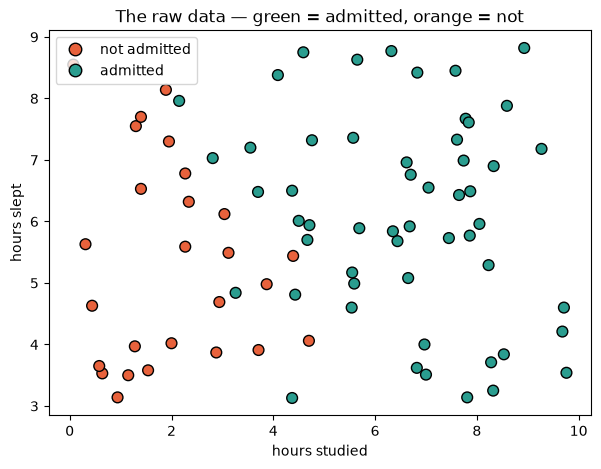

In [3]:
fig, ax = plt.subplots()
ax.scatter(X_raw[:, 0], X_raw[:, 1], c=y.ravel(), cmap=CMAP_PTS, edgecolors="k", s=60)
ax.set_xlabel("hours studied"); ax.set_ylabel("hours slept")
ax.set_title("The raw data — green = admitted, orange = not")
handles = [plt.Line2D([], [], marker="o", ls="", mec="k", mfc=c, ms=9)
           for c in ["#e8623c", "#2a9d8f"]]
ax.legend(handles, ["not admitted", "admitted"], loc="upper left")
plt.show()

## 3. The model — a few lines instead of four weight arrays

In the from-scratch notebook we hand-created four arrays: `W1, b1, W2, b2`, and did the
matrix multiplies ourselves. In PyTorch a `nn.Linear(in, out)` layer **is** a
weight+bias pair, and `nn.Sequential` chains layers into the forward pass:

```
inputs (2) -> Linear -> ReLU -> Linear -> (1 logit)
```

| from-scratch (numpy)      | PyTorch                    |
|---------------------------|----------------------------|
| `W1` (2×H), `b1`          | `net[0]` = `nn.Linear(2, H)` |
| `np.maximum(0, z1)`       | `net[1]` = `nn.ReLU()`       |
| `W2` (H×1), `b2`          | `net[2]` = `nn.Linear(H, 1)` |

One difference: the model outputs a raw **logit** (the number *before* sigmoid). We
apply sigmoid later, only when we want a probability — this is more numerically stable
(see the loss below).

In [4]:
def make_model(hidden_units=8, seed=0):
    torch.manual_seed(seed)          # reproducible starting weights
    return nn.Sequential(
        nn.Linear(2, hidden_units),  # inputs -> hidden   (this holds W1, b1)
        nn.ReLU(),                   # the non-linearity
        nn.Linear(hidden_units, 1),  # hidden -> 1 output (this holds W2, b2)
    )

demo = make_model(hidden_units=8, seed=0)
n_params = sum(p.numel() for p in demo.parameters())
print(demo)
print(f"\ntotal learnable numbers (weights + biases): {n_params}")

Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)

total learnable numbers (weights + biases): 33


## 4. The training loop — where `loss.backward()` earns its keep

This is the whole point. Compare the inner loop to the numpy version:

| step | from-scratch (numpy) | PyTorch |
|------|----------------------|---------|
| clear old gradients | (we overwrote them) | `opt.zero_grad()` |
| forward pass | `z1=X@W1+b1; a1=relu(z1); z2=a1@W2+b2` | `logits = model(Xt)` |
| loss | hand-written cross-entropy | `criterion(logits, yt)` |
| **backward pass** | **~8 lines: `dz2, dW2, db2, da1, dz1, dW1, db1`** | **`loss.backward()`** |
| update weights | `W2 -= lr*dW2; ...` (4 lines) | `opt.step()` |

`nn.BCEWithLogitsLoss` combines sigmoid + binary-cross-entropy in one numerically
stable step — that's why the model outputs a logit and we don't call sigmoid ourselves
during training.

As before, we record loss and accuracy every epoch so we can plot the learning curve.

In [5]:
def train_torch(hidden_units=8, learning_rate=0.1, epochs=400, seed=0, optimizer="SGD"):
    model = make_model(hidden_units, seed)
    criterion = nn.BCEWithLogitsLoss()          # sigmoid + cross-entropy, stable
    if optimizer == "Adam":
        opt = torch.optim.Adam(model.parameters(), lr=learning_rate)
    else:
        opt = torch.optim.SGD(model.parameters(), lr=learning_rate)

    hist = {"loss": [], "acc": []}
    for epoch in range(epochs):
        opt.zero_grad()               # 1. clear last step's gradients
        logits = model(Xt)            # 2. forward pass  (make predictions)
        loss = criterion(logits, yt)  # 3. how wrong are we?
        loss.backward()               # 4. THE backward pass — autograd fills every .grad
        opt.step()                    # 5. nudge every weight downhill

        with torch.no_grad():
            probs = torch.sigmoid(logits)
            acc = ((probs > 0.5) == (yt > 0.5)).float().mean().item()
        hist["loss"].append(loss.item())
        hist["acc"].append(acc)
    return model, hist

def predict_proba(model, X_np):
    # probability of 'admitted' for each row of (normalized) X_np
    with torch.no_grad():
        logits = model(torch.tensor(X_np, dtype=torch.float32))
        return torch.sigmoid(logits).numpy()

print("train_torch() and predict_proba() defined")

train_torch() and predict_proba() defined


### Reading the last part of that loop

After `opt.step()` has updated the weights, the rest of the loop just **measures and records** how we're doing:

- **`with torch.no_grad():`** — "don't track gradients in here." PyTorch normally watches every tensor operation so it can run `loss.backward()` later. We're only *measuring* now, not training, so we switch that bookkeeping off — it's faster and saves memory.
- **`probs = torch.sigmoid(logits)`** — the model outputs raw **logits** (any number); `sigmoid` squashes each into a **probability** in (0, 1). Training used `BCEWithLogitsLoss`, which applied sigmoid internally, so we apply it ourselves here to get a human-readable probability.
- **`acc = ((probs > 0.5) == (yt > 0.5)).float().mean().item()`** — accuracy in one line, read inside-out:
  - `probs > 0.5` → the model's guess (admitted / not) for each student
  - `yt > 0.5` → the true label as a boolean
  - `==` → `True` where the guess matches reality (a correct prediction)
  - `.float()` → turn `True/False` into `1.0/0.0`
  - `.mean()` → the fraction that are 1.0 = **proportion correct**
  - `.item()` → pull that single value out of the tensor as a plain Python number
- **`hist["loss"].append(loss.item())` / `hist["acc"].append(acc)`** — save this epoch's numbers (these lines sit *outside* `no_grad` — they're just appending). `.item()` again converts a one-value tensor back into an ordinary Python float.
- **`return model, hist`** — hand back the trained model and the recorded history, which §5 plots as the loss-down / accuracy-up curves.

**Remember:** `.item()` is how you cross from a single-value PyTorch tensor back to a plain Python number, and `torch.no_grad()` marks a block as "inspection only, not training.\"

## 5. Train it and watch it learn

Same two curves as the first notebook: loss should slide **down**, accuracy should
climb **up**.

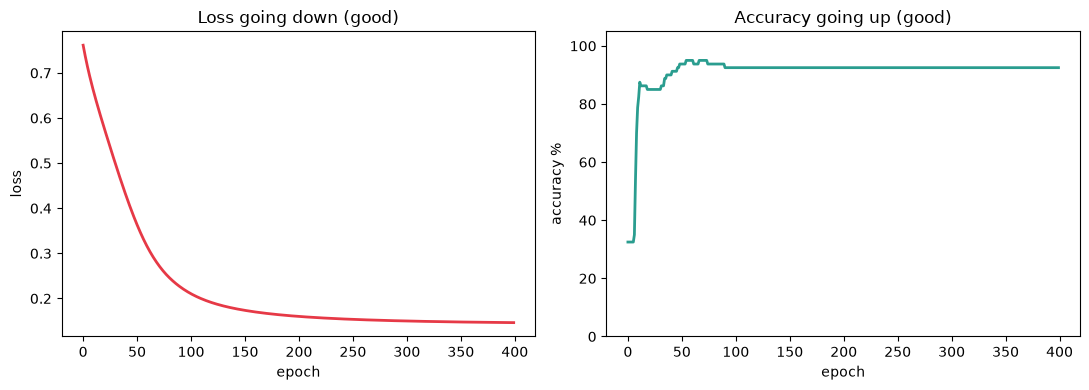

final loss 0.1465   final accuracy 92.5%


In [6]:
model, hist = train_torch(hidden_units=8, learning_rate=0.1, epochs=400, seed=0)

fig, (axL, axA) = plt.subplots(1, 2, figsize=(11, 4))
axL.plot(hist["loss"], color="#e63946", lw=2)
axL.set_title("Loss going down (good)"); axL.set_xlabel("epoch"); axL.set_ylabel("loss")
axA.plot(np.array(hist["acc"]) * 100, color="#2a9d8f", lw=2)
axA.set_title("Accuracy going up (good)"); axA.set_xlabel("epoch"); axA.set_ylabel("accuracy %")
axA.set_ylim(0, 105)
plt.tight_layout(); plt.show()

print(f"final loss {hist['loss'][-1]:.4f}   final accuracy {hist['acc'][-1]:.1%}")

## 6. The decision boundary

Colour the whole input space by what the model predicts. Green = "admitted", orange =
"not". The dots are the real students; where a dot's colour matches its background, the
model got it right.

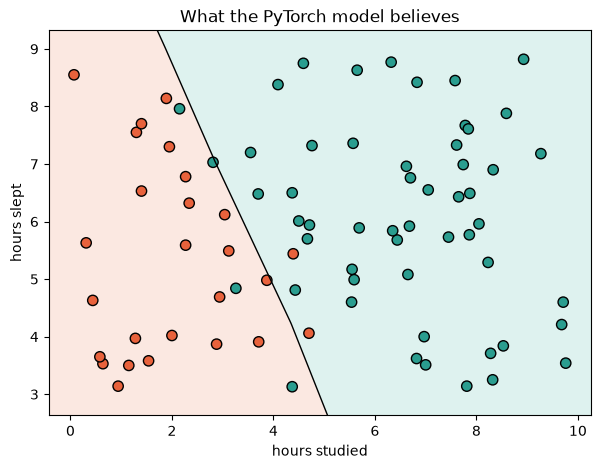

In [7]:
def plot_decision_boundary(model, ax=None, title="Decision boundary"):
    if ax is None:
        _, ax = plt.subplots()
    xs = np.linspace(X_raw[:, 0].min() - 0.5, X_raw[:, 0].max() + 0.5, 200)
    ys = np.linspace(X_raw[:, 1].min() - 0.5, X_raw[:, 1].max() + 0.5, 200)
    gx, gy = np.meshgrid(xs, ys)
    grid = np.c_[gx.ravel(), gy.ravel()]
    grid_norm = (grid - mean) / std                  # normalize like training
    probs = predict_proba(model, grid_norm).reshape(gx.shape)

    ax.contourf(gx, gy, probs, levels=[0, 0.5, 1], cmap=CMAP_BG, alpha=0.8)
    ax.contour(gx, gy, probs, levels=[0.5], colors="k", linewidths=1)
    ax.scatter(X_raw[:, 0], X_raw[:, 1], c=y.ravel(), cmap=CMAP_PTS, edgecolors="k", s=55)
    ax.set_xlabel("hours studied"); ax.set_ylabel("hours slept"); ax.set_title(title)
    return ax

plot_decision_boundary(model, title="What the PyTorch model believes")
plt.show()

## 7. Proof: PyTorch computes the *same* gradients you did by hand ✅

This is the heart of the notebook. We take **one** forward+backward step, using the
**same starting weights** in both worlds, and check that:

- the **loss** matches, and
- the **gradient** PyTorch put in `net[0].weight.grad` equals the `dW1` your numpy code
  computed by hand.

To make the comparison exact we use double precision (float64) on both sides. If these
agree to ~1e-6, then `loss.backward()` really is doing the same chain-rule calculus you
wrote out — just automatically.

In [8]:
# ---- (a) the hand-written gradients, straight from the first notebook ----
def hand_gradients(X, y, W1, b1, W2, b2):
    n = X.shape[0]
    z1 = X @ W1 + b1
    a1 = np.maximum(0, z1)
    z2 = a1 @ W2 + b2
    preds = 1.0 / (1.0 + np.exp(-z2))          # sigmoid
    eps = 1e-8
    loss = -np.mean(y * np.log(preds + eps) + (1 - y) * np.log(1 - preds + eps))
    dz2 = (preds - y) / n
    dW2 = a1.T @ dz2
    da1 = dz2 @ W2.T
    dz1 = da1 * (z1 > 0)
    dW1 = X.T @ dz1
    return loss, dW1, dW2

# pick some shared starting weights (float64)
rng = np.random.default_rng(0)
H = 8
W1 = rng.normal(0, 0.5, size=(2, H));  b1 = np.zeros((1, H))
W2 = rng.normal(0, 0.5, size=(H, 1));  b2 = np.zeros((1, 1))

hand_loss, hand_dW1, hand_dW2 = hand_gradients(X, y, W1, b1, W2, b2)

# ---- (b) the SAME model in PyTorch, with the SAME weights, one backward step ----
net = nn.Sequential(nn.Linear(2, H), nn.ReLU(), nn.Linear(H, 1)).double()
with torch.no_grad():
    net[0].weight.copy_(torch.tensor(W1.T))    # Linear stores weight as (out, in) = W1.T
    net[0].bias.copy_(torch.tensor(b1.ravel()))
    net[2].weight.copy_(torch.tensor(W2.T))
    net[2].bias.copy_(torch.tensor(b2.ravel()))

Xd = torch.tensor(X, dtype=torch.float64)
yd = torch.tensor(y, dtype=torch.float64)
torch_loss = nn.BCEWithLogitsLoss()(net(Xd), yd)
torch_loss.backward()                          # <-- the one line that replaces ~8

torch_dW1 = net[0].weight.grad.numpy().T       # back to (2, H) to compare with hand_dW1

# ---- (c) compare ----
print(f"loss   — hand: {hand_loss:.10f}   torch: {torch_loss.item():.10f}")
print(f"        max |difference| in dW1 gradient: {np.abs(hand_dW1 - torch_dW1).max():.2e}")
print(f"        max |difference| in dW2 gradient: {np.abs(hand_dW2 - net[2].weight.grad.numpy().T).max():.2e}")
match = np.allclose(hand_dW1, torch_dW1, atol=1e-6) and np.allclose(hand_dW2, net[2].weight.grad.numpy().T, atol=1e-6)
print("\n✅ SAME gradients — autograd matches the hand-written chain rule!" if match
      else "❌ mismatch")

loss   — hand: 0.6826342570   torch: 0.6826342769
        max |difference| in dW1 gradient: 2.78e-17
        max |difference| in dW2 gradient: 1.39e-17

✅ SAME gradients — autograd matches the hand-written chain rule!


So `loss.backward()` isn't magic — it's exactly the calculus from the first
notebook, computed for you. As models get bigger (thousands of layers), writing those
gradients by hand becomes impossible; `autograd` scales effortlessly. That is *the*
reason frameworks like PyTorch exist.

## 8. 🎛️ Play with the training knobs

Same sliders as before — plus one PyTorch gives us almost for free: the **optimizer**.
Switch between plain **SGD** and **Adam** (an adaptive optimizer) and watch how much
faster the loss drops.

- **hidden units** — model capacity (1 = straight-line boundary; more = curvier).
- **learning rate** — step size; the finickiest knob.
- **epochs** — how many passes over the data.
- **seed** — the random starting weights.
- **optimizer** — SGD vs Adam.

In [9]:
def explore(hidden_units, learning_rate, epochs, seed, optimizer):
    model, hist = train_torch(hidden_units, learning_rate, epochs, seed, optimizer)

    fig, (axL, axB) = plt.subplots(1, 2, figsize=(12, 4.5))
    axL.plot(hist["loss"], color="#e63946", lw=2)
    axL.set_title(f"Loss  ({optimizer}, final {hist['loss'][-1]:.3f})")
    axL.set_xlabel("epoch"); axL.set_ylabel("loss"); axL.set_ylim(bottom=0)

    plot_decision_boundary(model, ax=axB,
                           title=f"Decision boundary  (accuracy {hist['acc'][-1]:.0%})")
    plt.tight_layout(); plt.show()

interact(
    explore,
    hidden_units=IntSlider(value=8, min=1, max=32, step=1, description="hidden units"),
    learning_rate=FloatSlider(value=0.1, min=0.001, max=1.5, step=0.001,
                              readout_format=".3f", description="learn rate"),
    epochs=IntSlider(value=400, min=10, max=3000, step=10, description="epochs"),
    seed=IntSlider(value=0, min=0, max=20, step=1, description="seed"),
    optimizer=Dropdown(options=["SGD", "Adam"], value="SGD", description="optimizer"),
);

interactive(children=(IntSlider(value=8, description='hidden units', max=32, min=1), FloatSlider(value=0.1, de…

**Try:** set the optimizer to **Adam** with a small learning rate (0.01) — notice
it reaches a low loss in far fewer epochs than SGD. Then push SGD's learning rate up to
~1.4 and watch the loss curve get jumpy.

## 9. 🎓 Ask the model about one student

Train once with sensible settings, then move the two sliders to describe a student. The
bar shows the predicted probability of admission; the ★ shows where they sit on the map.

In [10]:
trained, _ = train_torch(hidden_units=8, learning_rate=0.1, epochs=800, seed=0)

def ask(hours_studied, hours_slept):
    x = (np.array([[hours_studied, hours_slept]]) - mean) / std
    p = float(predict_proba(trained, x)[0, 0])

    fig, (axP, axB) = plt.subplots(1, 2, figsize=(12, 4.5),
                                   gridspec_kw={"width_ratios": [1, 1.4]})
    axP.barh([0], [p], color="#2a9d8f" if p >= 0.5 else "#e8623c", height=0.5)
    axP.set_xlim(0, 1); axP.set_ylim(-1, 1); axP.set_yticks([])
    axP.axvline(0.5, color="gray", ls="--")
    axP.set_title(f"admitted probability: {p:.0%}")
    axP.text(p, 0.6, f"{p:.0%}", ha="center", fontsize=13, fontweight="bold")

    plot_decision_boundary(trained, ax=axB, title="this student (★) on the map")
    axB.scatter([hours_studied], [hours_slept], marker="*", s=420,
                color="gold", edgecolors="k", zorder=5)
    plt.tight_layout(); plt.show()

    verdict = "ADMITTED" if p >= 0.5 else "NOT admitted"
    print(f"studied {hours_studied}h, slept {hours_slept}h  ->  {verdict}  ({p:.1%})")

interact(
    ask,
    hours_studied=FloatSlider(value=6, min=0, max=12, step=0.1, description="studied (h)"),
    hours_slept=FloatSlider(value=6, min=0, max=12, step=0.1, description="slept (h)"),
);

interactive(children=(FloatSlider(value=6.0, description='studied (h)', max=12.0), FloatSlider(value=6.0, desc…

## 10. Recap — what PyTorch gave you

You rebuilt the from-scratch network and got three things for free:

- **`nn.Linear` / `nn.Sequential`** — layers instead of hand-managed weight arrays.
- **`autograd` (`loss.backward()`)** — the entire backward pass, computed automatically,
  and (Section 7) numerically identical to your hand-written gradients.
- **`torch.optim`** — ready-made optimizers like Adam, a one-word swap.

The math didn't change — you *proved* that. What changed is that you no longer write the
calculus, which is what makes million-parameter models practical.

**Your next rung:** the one thing both notebooks quietly cheat on — they measure accuracy
on the *same data they trained on*. Real ML lives or dies on **held-out** data. Add a
train/validation split, watch the two loss curves diverge, and you'll have met
**overfitting** — the central problem of machine learning. After that: swap this tabular
data for images and meet convolutional networks.